In [1]:
print("My hospital readmission project has started!")

My hospital readmission project has started!


In [2]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Load datasets
patients = pd.read_csv("Data/Raw/patients.csv")
encounters = pd.read_csv("Data/Raw/encounters.csv")
conditions = pd.read_csv("Data/Raw/conditions.csv")

In [5]:
# Shape of the datasets
print("Patients shape:", patients.shape)
print("Encounters shape:", encounters.shape)
print("Conditions shape:", conditions.shape)


Patients shape: (117, 28)
Encounters shape: (8316, 15)
Conditions shape: (4023, 7)


# Initial data understanding
Initial Data Understanding

Before building the model, it is important to understand:
- column structure
- dataset size
- data types
- missing values
- sample records
  

In [14]:
print("\nPatients columns:\n", patients.columns.tolist())
print("\nEncounters columns:\n", encounters.columns.tolist())
print("\nConditions columns:\n", conditions.columns.tolist())


Patients columns:
 ['Id', 'BIRTHDATE', 'DEATHDATE', 'SSN', 'DRIVERS', 'PASSPORT', 'PREFIX', 'FIRST', 'MIDDLE', 'LAST', 'SUFFIX', 'MAIDEN', 'MARITAL', 'RACE', 'ETHNICITY', 'GENDER', 'BIRTHPLACE', 'ADDRESS', 'CITY', 'STATE', 'COUNTY', 'FIPS', 'ZIP', 'LAT', 'LON', 'HEALTHCARE_EXPENSES', 'HEALTHCARE_COVERAGE', 'INCOME']

Encounters columns:
 ['Id', 'START', 'STOP', 'PATIENT', 'ORGANIZATION', 'PROVIDER', 'PAYER', 'ENCOUNTERCLASS', 'CODE', 'DESCRIPTION', 'BASE_ENCOUNTER_COST', 'TOTAL_CLAIM_COST', 'PAYER_COVERAGE', 'REASONCODE', 'REASONDESCRIPTION']

Conditions columns:
 ['START', 'STOP', 'PATIENT', 'ENCOUNTER', 'SYSTEM', 'CODE', 'DESCRIPTION']


In [15]:
print("\n--- Patients Info ---")
patients.info()

print("\n--- Encounters Info ---")
encounters.info()

print("\n--- Conditions Info ---")
conditions.info()


--- Patients Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 117 entries, 0 to 116
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Id                   117 non-null    object 
 1   BIRTHDATE            117 non-null    object 
 2   DEATHDATE            17 non-null     object 
 3   SSN                  117 non-null    object 
 4   DRIVERS              100 non-null    object 
 5   PASSPORT             98 non-null     object 
 6   PREFIX               98 non-null     object 
 7   FIRST                117 non-null    object 
 8   MIDDLE               99 non-null     object 
 9   LAST                 117 non-null    object 
 10  SUFFIX               3 non-null      object 
 11  MAIDEN               39 non-null     object 
 12  MARITAL              89 non-null     object 
 13  RACE                 117 non-null    object 
 14  ETHNICITY            117 non-null    object 
 15  GENDER           

In [16]:
display(patients.head())
display(encounters.head())
display(conditions.head())

,Id,BIRTHDATE,DEATHDATE,SSN,DRIVERS,PASSPORT,PREFIX,FIRST,MIDDLE,LAST,...,CITY,STATE,COUNTY,FIPS,ZIP,LAT,LON,HEALTHCARE_EXPENSES,HEALTHCARE_COVERAGE,INCOME
0,f1aa52b9-aded-3188-9386-012244805ebf,1989-06-20,NaN,999-96-7640,S99993266,X52137231X,Mr.,Maurice742,Corey514,Brekke496,...,Dedham,Massachusetts,Norfolk County,25021.0,2090,42.294422,-71.141595,182949.51,22601.32,108063
1,d30ace70-ad74-f9a6-2433-a5f28a25a03d,1970-06-07,NaN,999-80-5045,S99934663,X57379994X,Mrs.,Débora815,Verónica383,Montes106,...,Woburn,Massachusetts,Middlesex County,25017.0,1890,42.497181,-71.193682,350449.26,738677.48,30032
2,cd42752c-2467-db64-102c-73d9b3b4f218,1990-03-23,NaN,999-58-3815,S99960338,X2841412X,Mrs.,Lekisha909,Lurline371,Bosco882,...,Natick,Massachusetts,Middlesex County,NaN,0,42.273299,-71.303382,181444.45,1175449.91,132744
3,182b5fa5-9a66-b61f-0ca4-0106c17f92a8,1954-03-26,NaN,999-37-7227,S99917941,X36873868X,Mrs.,Berta524,Carmen818,Escobar593,...,Saugus,Massachusetts,Essex County,25009.0,1906,42.515774,-71.017220,778776.76,117169.66,78140
4,e972e250-fba2-a39f-81e9-25f7df4f83a2,2017-05-12,NaN,999-22-5525,NaN,NaN,NaN,Bryon392,Reid278,Runte676,...,Chelmsford,Massachusetts,Middlesex County,NaN,0,42.620652,-71.365034,1616.96,26415.77,12994


,Id,START,STOP,PATIENT,ORGANIZATION,PROVIDER,PAYER,ENCOUNTERCLASS,CODE,DESCRIPTION,BASE_ENCOUNTER_COST,TOTAL_CLAIM_COST,PAYER_COVERAGE,REASONCODE,REASONDESCRIPTION
0,f1aa52b9-aded-3188-89de-02f5e685ce85,2007-08-28T13:10:24Z,2007-08-28T13:52:05Z,f1aa52b9-aded-3188-9386-012244805ebf,50c47685-8125-3c50-8311-8bd7ba9e9108,c43464a9-e8d8-3dde-87ec-abccb3e401fb,d31fccc3-1767-390d-966a-22a5156f4219,wellness,162673000,General examination of patient (procedure),136.80,704.20,0.00,NaN,NaN
1,f1aa52b9-aded-3188-0421-249ad1d4b3c3,2008-09-23T13:10:24Z,2008-09-23T14:26:15Z,f1aa52b9-aded-3188-9386-012244805ebf,5862e05c-9533-3f7a-8f73-215d50f5ee2f,07f8c30e-bd80-374a-be32-f7743add7858,d31fccc3-1767-390d-966a-22a5156f4219,ambulatory,185347001,Encounter for problem (procedure),85.55,1379.75,1103.80,37320007.0,Loss of teeth (disorder)
2,f1aa52b9-aded-3188-de91-a20f5d025d3e,2011-09-06T13:10:24Z,2011-09-06T13:44:22Z,f1aa52b9-aded-3188-9386-012244805ebf,50c47685-8125-3c50-8311-8bd7ba9e9108,c43464a9-e8d8-3dde-87ec-abccb3e401fb,d31fccc3-1767-390d-966a-22a5156f4219,wellness,162673000,General examination of patient (procedure),136.80,1186.78,0.00,NaN,NaN
3,f1aa52b9-aded-3188-1afd-3e0e9c0bfe43,2016-05-01T02:10:24Z,2016-05-01T02:27:24Z,f1aa52b9-aded-3188-9386-012244805ebf,5862e05c-9533-3f7a-8f73-215d50f5ee2f,07f8c30e-bd80-374a-be32-f7743add7858,d31fccc3-1767-390d-966a-22a5156f4219,ambulatory,185345009,Encounter for symptom (procedure),85.55,642.27,513.82,10509002.0,Acute bronchitis (disorder)
4,f1aa52b9-aded-3188-0937-f004b659f1b5,2016-05-10T13:10:24Z,2016-05-10T13:44:02Z,f1aa52b9-aded-3188-9386-012244805ebf,04b252db-4231-3cb5-963d-6f096fb4b97c,40212066-46b4-34ab-807d-221ed3e21014,d31fccc3-1767-390d-966a-22a5156f4219,urgentcare,702927004,Urgent care clinic (environment),142.58,709.98,567.98,NaN,NaN


,START,STOP,PATIENT,ENCOUNTER,SYSTEM,CODE,DESCRIPTION
0,2007-08-28,NaN,f1aa52b9-aded-3188-9386-012244805ebf,f1aa52b9-aded-3188-89de-02f5e685ce85,http://snomed.info/sct,105531004,Housing unsatisfactory (finding)
1,2007-08-28,NaN,f1aa52b9-aded-3188-9386-012244805ebf,f1aa52b9-aded-3188-89de-02f5e685ce85,http://snomed.info/sct,224299000,Received higher education (finding)
2,2008-09-23,NaN,f1aa52b9-aded-3188-9386-012244805ebf,f1aa52b9-aded-3188-0421-249ad1d4b3c3,http://snomed.info/sct,37320007,Loss of teeth (disorder)
3,2011-09-06,2016-05-10,f1aa52b9-aded-3188-9386-012244805ebf,f1aa52b9-aded-3188-de91-a20f5d025d3e,http://snomed.info/sct,160903007,Full-time employment (finding)
4,2016-05-01,2016-05-12,f1aa52b9-aded-3188-9386-012244805ebf,f1aa52b9-aded-3188-1afd-3e0e9c0bfe43,http://snomed.info/sct,10509002,Acute bronchitis (disorder)


## Prepare Encounter Data

Since readmission analysis depends on admission and discharge timing, we first:
- convert encounter dates into datetime format
- remove timezone information if present
- inspect encounter class distribution

In [17]:
encounters["START"] = pd.to_datetime(encounters["START"], errors="coerce")
encounters["STOP"] = pd.to_datetime(encounters["STOP"], errors="coerce")

encounters["START"] = encounters["START"].dt.tz_localize(None)
encounters["STOP"] = encounters["STOP"].dt.tz_localize(None)

print("\nEncounter class distribution:")
print(encounters["ENCOUNTERCLASS"].value_counts(dropna=False))


Encounter class distribution:
ENCOUNTERCLASS
ambulatory    5253
wellness      1433
outpatient     853
emergency      274
inpatient      229
urgentcare     171
home            59
hospice         18
snf             14
virtual         12
Name: count, dtype: int64


## Filter Inpatient Encounters

Readmission analysis is typically focused on **inpatient admissions**, so this section:
- keeps only inpatient encounters
- removes rows with missing key dates
- sorts each patient’s admissions by time

In [18]:
inpatient = encounters.loc[encounters["ENCOUNTERCLASS"] == "inpatient"].copy()
inpatient = inpatient.dropna(subset=["PATIENT", "START", "STOP"])
inpatient = inpatient.sort_values(["PATIENT", "START"]).reset_index(drop=True)

print("Inpatient shape:", inpatient.shape)
display(inpatient[["PATIENT", "START", "STOP"]].head(10))

Inpatient shape: (229, 15)


,PATIENT,START,STOP
0,03d2e5e6-a126-d0de-0a38-3f0bad766b30,2012-03-11 22:04:50,2012-03-12 22:04:50
1,06ee89b1-5a9a-4d2f-0760-fe3d99a1362f,2021-05-01 11:08:10,2021-05-07 16:08:10
2,06ee89b1-5a9a-4d2f-0760-fe3d99a1362f,2025-03-09 23:40:50,2025-03-12 01:47:16
3,08c6ca9c-1ba6-97b5-0c33-65f7755af0e2,2015-12-08 12:26:55,2015-12-09 12:26:55
4,08ed9178-5075-8d7d-644c-fa31406f67bd,2020-11-09 11:12:18,2020-11-12 11:12:18
5,08ed9178-5075-8d7d-644c-fa31406f67bd,2021-02-01 13:14:36,2021-02-16 03:46:27
6,0a42ee5e-12a8-b004-5b5c-1cef952f0824,2024-08-02 19:02:58,2024-08-04 14:31:27
7,0c193146-985b-c33e-07fe-6f474df3336c,2023-06-12 07:20:47,2023-06-18 23:10:05
8,146f90af-2cfb-f2a9-1bf5-998b37420c0d,2004-11-28 15:36:16,2004-11-29 15:36:16
9,182b5fa5-9a66-b61f-0ca4-0106c17f92a8,2021-03-09 17:36:31,2021-03-12 17:36:31


## For each inpatient admission, we identify the next admission for the same patient and calculate how many days passed between discharge and the next admission.

A patient is labeled as **readmitted within 30 days** if:
- a future inpatient admission exists
- it occurs within 30 days after discharge

In [19]:
inpatient["next_admission"] = inpatient.groupby("PATIENT")["START"].shift(-1)
inpatient["days_to_next"] = (inpatient["next_admission"] - inpatient["STOP"]).dt.days

inpatient["readmitted_30_days"] = (
    inpatient["days_to_next"].notna() &
    (inpatient["days_to_next"] >= 0) &
    (inpatient["days_to_next"] <= 30)
).astype(int)

print("\nReadmission label counts:")
print(inpatient["readmitted_30_days"].value_counts())

print("\n30-day readmission rate:")
print(round(inpatient["readmitted_30_days"].mean(), 4))

display(
    inpatient[["PATIENT", "START", "STOP", "next_admission", "days_to_next", "readmitted_30_days"]]
    .head(10)
)


Readmission label counts:
readmitted_30_days
0    168
1     61
Name: count, dtype: int64

30-day readmission rate:
0.2664


,PATIENT,START,STOP,next_admission,days_to_next,readmitted_30_days
0,03d2e5e6-a126-d0de-0a38-3f0bad766b30,2012-03-11 22:04:50,2012-03-12 22:04:50,NaT,NaN,0
1,06ee89b1-5a9a-4d2f-0760-fe3d99a1362f,2021-05-01 11:08:10,2021-05-07 16:08:10,2025-03-09 23:40:50,1402.0,0
2,06ee89b1-5a9a-4d2f-0760-fe3d99a1362f,2025-03-09 23:40:50,2025-03-12 01:47:16,NaT,NaN,0
3,08c6ca9c-1ba6-97b5-0c33-65f7755af0e2,2015-12-08 12:26:55,2015-12-09 12:26:55,NaT,NaN,0
4,08ed9178-5075-8d7d-644c-fa31406f67bd,2020-11-09 11:12:18,2020-11-12 11:12:18,2021-02-01 13:14:36,81.0,0
5,08ed9178-5075-8d7d-644c-fa31406f67bd,2021-02-01 13:14:36,2021-02-16 03:46:27,NaT,NaN,0
6,0a42ee5e-12a8-b004-5b5c-1cef952f0824,2024-08-02 19:02:58,2024-08-04 14:31:27,NaT,NaN,0
7,0c193146-985b-c33e-07fe-6f474df3336c,2023-06-12 07:20:47,2023-06-18 23:10:05,NaT,NaN,0
8,146f90af-2cfb-f2a9-1bf5-998b37420c0d,2004-11-28 15:36:16,2004-11-29 15:36:16,NaT,NaN,0
9,182b5fa5-9a66-b61f-0ca4-0106c17f92a8,2021-03-09 17:36:31,2021-03-12 17:36:31,2021-06-09 19:42:40,89.0,0


## Merge Patient Demographics

To enrich inpatient encounter data, we merge the patient dataset into the inpatient dataset using the patient identifier.

In [20]:
analysis_df = inpatient.merge(
    patients,
    left_on="PATIENT",
    right_on="Id",
    how="left"
)

print("Analysis dataset shape after patient merge:", analysis_df.shape)
display(analysis_df.head())

Analysis dataset shape after patient merge: (229, 46)


,Id_x,START,STOP,PATIENT,ORGANIZATION,PROVIDER,PAYER,ENCOUNTERCLASS,CODE,DESCRIPTION,...,CITY,STATE,COUNTY,FIPS,ZIP,LAT,LON,HEALTHCARE_EXPENSES,HEALTHCARE_COVERAGE,INCOME
0,03d2e5e6-a126-d0de-0c14-f898a6c0b74e,2012-03-11 22:04:50,2012-03-12 22:04:50,03d2e5e6-a126-d0de-0a38-3f0bad766b30,1e11392b-1278-3e70-93cd-f396cbd0c265,27f25c38-efaf-363b-a554-8ba9737148ff,26aab0cd-6aba-3e1b-ac5b-05c8867e762c,inpatient,305408004,Admission to surgical department (procedure),...,Natick,Massachusetts,Middlesex County,NaN,0,42.273506,-71.327822,548579.99,260024.63,73773
1,06ee89b1-5a9a-4d2f-7335-a6c254fce67f,2021-05-01 11:08:10,2021-05-07 16:08:10,06ee89b1-5a9a-4d2f-0760-fe3d99a1362f,5b0cd0a0-f277-3a66-bee6-d64b5be4a3f5,ac654e17-aecb-3309-9c4a-e64802327ede,26aab0cd-6aba-3e1b-ac5b-05c8867e762c,inpatient,305408004,Admission to surgical department (procedure),...,North Adams,Massachusetts,Berkshire County,25003.0,1247,42.678512,-73.142611,619928.91,613795.55,116198
2,06ee89b1-5a9a-4d2f-4f82-a9e1e4ad091e,2025-03-09 23:40:50,2025-03-12 01:47:16,06ee89b1-5a9a-4d2f-0760-fe3d99a1362f,5b0cd0a0-f277-3a66-bee6-d64b5be4a3f5,ac654e17-aecb-3309-9c4a-e64802327ede,26aab0cd-6aba-3e1b-ac5b-05c8867e762c,inpatient,185347001,Encounter for problem (procedure),...,North Adams,Massachusetts,Berkshire County,25003.0,1247,42.678512,-73.142611,619928.91,613795.55,116198
3,08c6ca9c-1ba6-97b5-939e-2fd171396162,2015-12-08 12:26:55,2015-12-09 12:26:55,08c6ca9c-1ba6-97b5-0c33-65f7755af0e2,74ab949d-17ac-3309-83a0-13b4405c66aa,f94bad87-d775-34ae-a123-4f9a3bc47b44,26aab0cd-6aba-3e1b-ac5b-05c8867e762c,inpatient,32485007,Hospital admission (procedure),...,Topsfield,Massachusetts,Essex County,25009.0,1983,42.643813,-70.968532,1243777.79,71297.55,71819
4,08ed9178-5075-8d7d-e637-32b17e2d5ced,2020-11-09 11:12:18,2020-11-12 11:12:18,08ed9178-5075-8d7d-644c-fa31406f67bd,eee00932-ca82-36bc-b7e8-e3fff6dbaeaa,02a50e1a-230d-367c-9206-02e7726a0731,a735bf55-83e9-331a-899d-a82a60b9f60c,inpatient,308251003,Admission to clinical oncology department (pro...,...,Hingham,Massachusetts,Plymouth County,25023.0,2043,42.217784,-70.890136,1286575.93,62013.84,101954


## Feature Engineering: Age

Age is calculated using:
- admission date (`START`)
- patient date of birth (`BIRTHDATE`)

This gives an approximate age in years at the time of admission.

In [21]:
analysis_df["BIRTHDATE"] = pd.to_datetime(analysis_df["BIRTHDATE"], errors="coerce")
analysis_df["BIRTHDATE"] = analysis_df["BIRTHDATE"].dt.tz_localize(None)

analysis_df["age"] = (
    (analysis_df["START"] - analysis_df["BIRTHDATE"]).dt.days / 365.25
)

analysis_df["age"] = analysis_df["age"].fillna(0).astype(int)

display(analysis_df[["PATIENT", "START", "BIRTHDATE", "age"]].head())

,PATIENT,START,BIRTHDATE,age
0,03d2e5e6-a126-d0de-0a38-3f0bad766b30,2012-03-11 22:04:50,1976-08-29,35
1,06ee89b1-5a9a-4d2f-0760-fe3d99a1362f,2021-05-01 11:08:10,1974-01-23,47
2,06ee89b1-5a9a-4d2f-0760-fe3d99a1362f,2025-03-09 23:40:50,1974-01-23,51
3,08c6ca9c-1ba6-97b5-0c33-65f7755af0e2,2015-12-08 12:26:55,1963-10-12,52
4,08ed9178-5075-8d7d-644c-fa31406f67bd,2020-11-09 11:12:18,1953-11-26,66


## Feature Engineering: Number of Conditions

To approximate patient disease burden, we count how many condition records exist for each patient.

This new variable is called **num_conditions**.

In [22]:
condition_counts = (
    conditions.groupby("PATIENT")
    .size()
    .reset_index(name="num_conditions")
)

analysis_df = analysis_df.merge(
    condition_counts,
    on="PATIENT",
    how="left"
)

analysis_df["num_conditions"] = analysis_df["num_conditions"].fillna(0).astype(int)

print("Condition count summary:")
display(analysis_df["num_conditions"].describe())

print("Average conditions by readmission status:")
display(analysis_df.groupby("readmitted_30_days", as_index=False)["num_conditions"].mean())

Condition count summary:


count    229.000000
mean      44.008734
std       17.564166
min       21.000000
25%       35.000000
50%       42.000000
75%       49.000000
max      152.000000
Name: num_conditions, dtype: float64

Average conditions by readmission status:


,readmitted_30_days,num_conditions
0,0,44.916667
1,1,41.508197


## Feature Engineering: Length of Stay

Length of stay is calculated as the difference between:
- discharge date (`STOP`)
- admission date (`START`)

This variable can be an important predictor of readmission risk.

In [23]:
analysis_df["length_of_stay"] = (analysis_df["STOP"] - analysis_df["START"]).dt.days
analysis_df.loc[analysis_df["length_of_stay"] < 0, "length_of_stay"] = pd.NA

display(analysis_df[["START", "STOP", "length_of_stay"]].head())

,START,STOP,length_of_stay
0,2012-03-11 22:04:50,2012-03-12 22:04:50,1.0
1,2021-05-01 11:08:10,2021-05-07 16:08:10,6.0
2,2025-03-09 23:40:50,2025-03-12 01:47:16,2.0
3,2015-12-08 12:26:55,2015-12-09 12:26:55,1.0
4,2020-11-09 11:12:18,2020-11-12 11:12:18,3.0


## Build Final Modeling Dataset

This section selects the final variables that will be used for:
- exploratory data analysis
- machine learning
- exporting the cleaned dataset

In [24]:
model_df = analysis_df[
    [
        "PATIENT",
        "START",
        "STOP",
        "ENCOUNTERCLASS",
        "length_of_stay",
        "days_to_next",
        "readmitted_30_days",
        "age",
        "GENDER",
        "RACE",
        "ETHNICITY",
        "MARITAL",
        "num_conditions",
    ]
].copy()

print("Model dataset shape:", model_df.shape)

print("\nMissing values in model dataset:")
display(model_df.isnull().sum())

Model dataset shape: (229, 13)

Missing values in model dataset:


PATIENT                0
START                  0
STOP                   0
ENCOUNTERCLASS         0
length_of_stay         0
days_to_next          51
readmitted_30_days     0
age                    0
GENDER                 0
RACE                   0
ETHNICITY              0
MARITAL                1
num_conditions         0
dtype: int64

## Handle Missing Values

Before analysis and modeling:
- numeric missing values are imputed
- categorical missing values are replaced with `"Unknown"`

In [25]:
model_df["length_of_stay"] = model_df["length_of_stay"].fillna(model_df["length_of_stay"].median())
model_df["age"] = model_df["age"].fillna(model_df["age"].median())
model_df["num_conditions"] = model_df["num_conditions"].fillna(0)

for col in ["GENDER", "RACE", "ETHNICITY", "MARITAL"]:
    model_df[col] = model_df[col].fillna("Unknown")

## Exploratory Data Analysis

This section explores how readmission is associated with:
- age
- length of stay
- number of conditions
- demographic factors such as gender and race

In [26]:
print("Readmission count:")
display(model_df["readmitted_30_days"].value_counts())

print("Readmission proportion:")
display(model_df["readmitted_30_days"].value_counts(normalize=True))

print("Average age by readmission status:")
display(model_df.groupby("readmitted_30_days")["age"].mean())

print("Average length of stay by readmission status:")
display(model_df.groupby("readmitted_30_days")["length_of_stay"].mean())

print("Average number of conditions by readmission status:")
display(model_df.groupby("readmitted_30_days")["num_conditions"].mean())

print("Readmission proportion by gender:")
display(pd.crosstab(model_df["GENDER"], model_df["readmitted_30_days"], normalize="index"))

print("Readmission proportion by race:")
display(pd.crosstab(model_df["RACE"], model_df["readmitted_30_days"], normalize="index"))

Readmission count:


readmitted_30_days
0    168
1     61
Name: count, dtype: int64

Readmission proportion:


readmitted_30_days
0    0.733624
1    0.266376
Name: proportion, dtype: float64

Average age by readmission status:


...

readmitted_30_days
0    44.916667
1    41.508197
Name: num_conditions, dtype: float64

Readmission proportion by gender:


readmitted_30_days,0,1
GENDER,,
F,0.819149,0.180851
M,0.674074,0.325926


Readmission proportion by race:


readmitted_30_days,0,1
RACE,,
asian,1.000000,0.000000
black,1.000000,0.000000
other,1.000000,0.000000
white,0.717593,0.282407


## Visualizations

The following visualizations help compare readmitted and non-readmitted groups across key features.

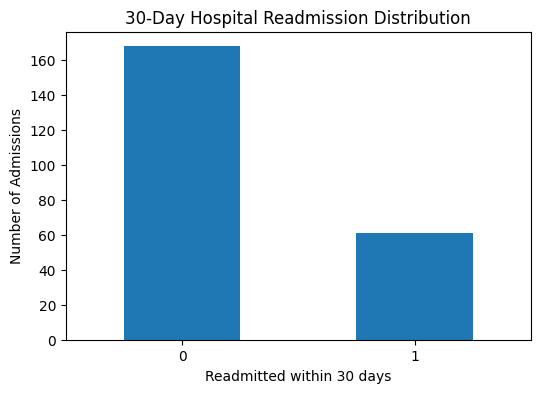

In [27]:
plt.figure(figsize=(6, 4))
model_df["readmitted_30_days"].value_counts().sort_index().plot(kind="bar")
plt.title("30-Day Hospital Readmission Distribution")
plt.xlabel("Readmitted within 30 days")
plt.ylabel("Number of Admissions")
plt.xticks(rotation=0)
plt.show()

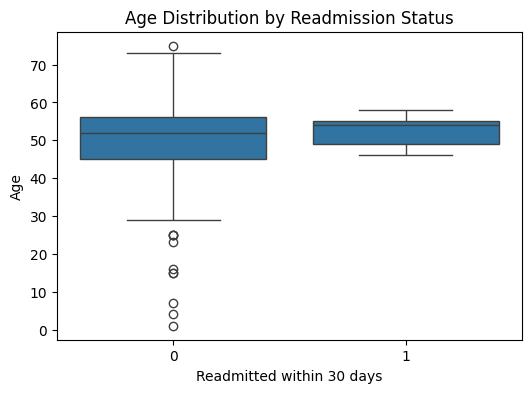

In [28]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=model_df, x="readmitted_30_days", y="age")
plt.title("Age Distribution by Readmission Status")
plt.xlabel("Readmitted within 30 days")
plt.ylabel("Age")
plt.show()

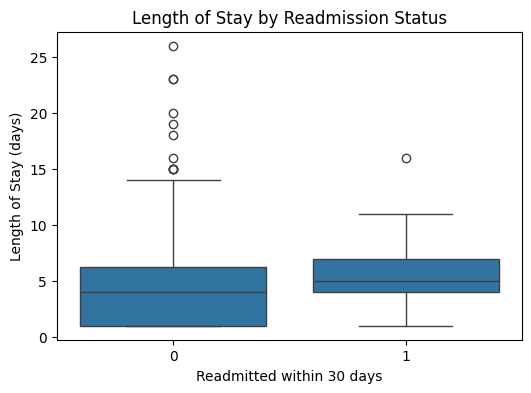

In [29]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=model_df, x="readmitted_30_days", y="length_of_stay")
plt.title("Length of Stay by Readmission Status")
plt.xlabel("Readmitted within 30 days")
plt.ylabel("Length of Stay (days)")
plt.show()

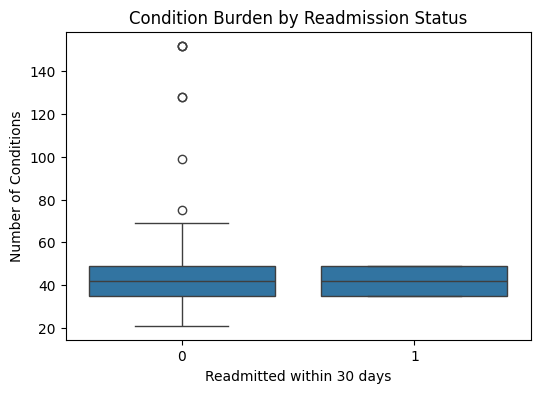

In [30]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=model_df, x="readmitted_30_days", y="num_conditions")
plt.title("Condition Burden by Readmission Status")
plt.xlabel("Readmitted within 30 days")
plt.ylabel("Number of Conditions")
plt.show()

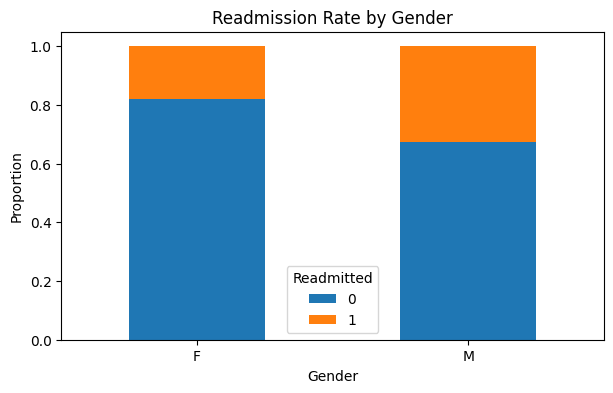

In [31]:
gender_readmit = pd.crosstab(
    model_df["GENDER"],
    model_df["readmitted_30_days"],
    normalize="index"
)

gender_readmit.plot(kind="bar", stacked=True, figsize=(7, 4))
plt.title("Readmission Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Proportion")
plt.legend(title="Readmitted")
plt.xticks(rotation=0)
plt.show()

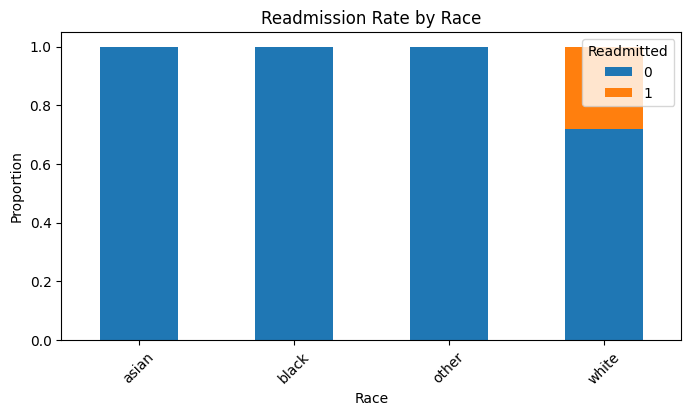

In [32]:
race_readmit = pd.crosstab(
    model_df["RACE"],
    model_df["readmitted_30_days"],
    normalize="index"
)

race_readmit.plot(kind="bar", stacked=True, figsize=(8, 4))
plt.title("Readmission Rate by Race")
plt.xlabel("Race")
plt.ylabel("Proportion")
plt.legend(title="Readmitted")
plt.xticks(rotation=45)
plt.show()

## Prepare Data for Machine Learning


In [33]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report

In [34]:
features = [
    "age",
    "length_of_stay",
    "num_conditions",
    "GENDER",
    "RACE",
    "MARITAL",
]

target = "readmitted_30_days"

X = model_df[features].copy()
y = model_df[target].copy()

X = pd.get_dummies(X, drop_first=True)

print("Feature matrix shape:", X.shape)
display(X.head())

Feature matrix shape: (229, 11)


,age,length_of_stay,num_conditions,GENDER_M,RACE_black,RACE_other,RACE_white,MARITAL_M,MARITAL_S,MARITAL_Unknown,MARITAL_W
0,35,1.0,23,False,False,False,True,True,False,False,False
1,47,6.0,26,False,False,False,True,True,False,False,False
2,51,2.0,26,False,False,False,True,True,False,False,False
3,52,1.0,41,False,False,False,True,True,False,False,False
4,66,3.0,34,False,False,False,True,True,False,False,False


## Split Data into Train and Test Sets

The dataset is split into:
- **training set (80%)**
- **testing set (20%)**

Stratified splitting is used to preserve class distribution in both sets.

In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (183, 11)
Testing set size: (46, 11)


## Train Logistic Regression Model

A logistic regression model is trained to predict whether an inpatient admission will be followed by a readmission within 30 days.

Class balancing is enabled to better handle any imbalance in the target variable.

In [36]:
model = LogisticRegression(max_iter=1000, class_weight="balanced")
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

/Users/shrutichaitanya/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/shrutichaitanya/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/shrutichaitanya/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/shrutichaitanya/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/shrutichaitanya/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: overflow encountered in matmul
  g

## Evaluate Model Performance

The model is evaluated using:
- confusion matrix
- precision
- recall
- F1-score

In [37]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[19 15]
 [ 4  8]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.56      0.67        34
           1       0.35      0.67      0.46        12

    accuracy                           0.59        46
   macro avg       0.59      0.61      0.56        46
weighted avg       0.70      0.59      0.61        46



## Interpret Feature Importance

For logistic regression, feature coefficients indicate how strongly each variable influences the prediction.

- positive coefficients increase the likelihood of readmission
- negative coefficients decrease the likelihood of readmission

In [38]:
importance = pd.Series(model.coef_[0], index=X.columns).sort_values(ascending=False)

print("Top positive coefficients:")
display(importance.head(10))

print("Top negative coefficients:")
display(importance.tail(10))

Top positive coefficients:


MARITAL_M          1.838220
RACE_white         0.990030
GENDER_M           0.561779
age                0.027162
length_of_stay    -0.025599
num_conditions    -0.038138
MARITAL_Unknown   -0.071158
RACE_other        -0.291469
MARITAL_W         -0.294180
RACE_black        -0.525407
dtype: float64

Top negative coefficients:


RACE_white         0.990030
GENDER_M           0.561779
age                0.027162
length_of_stay    -0.025599
num_conditions    -0.038138
MARITAL_Unknown   -0.071158
RACE_other        -0.291469
MARITAL_W         -0.294180
RACE_black        -0.525407
MARITAL_S         -0.642947
dtype: float64

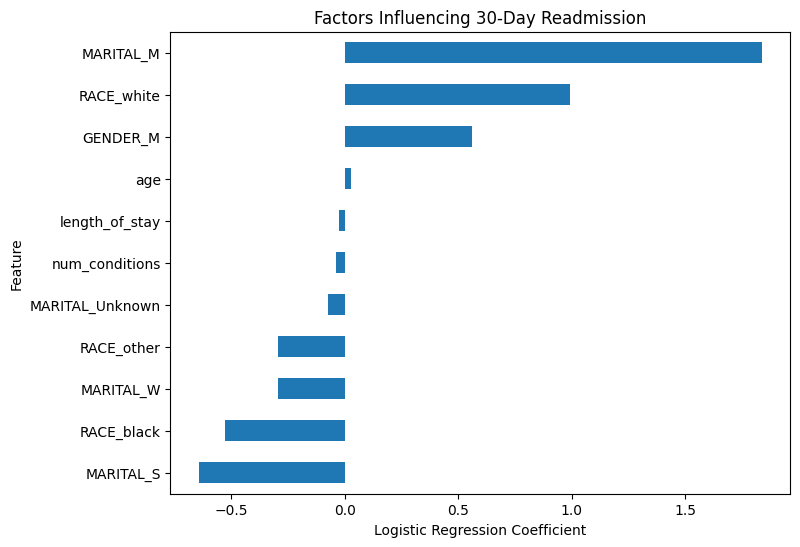

In [39]:
plt.figure(figsize=(8, 6))
importance.sort_values().plot(kind="barh")
plt.title("Factors Influencing 30-Day Readmission")
plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")
plt.show()

## Export Processed Dataset

The final cleaned dataset is exported for:
- dashboard development
- reporting
- further analysis

In [40]:
model_df.to_csv("Data/processed/readmission_dashboard_data.csv", index=False)

print("Processed dataset exported successfully to:")
print("Data/processed/readmission_dashboard_data.csv")

Processed dataset exported successfully to:
Data/processed/readmission_dashboard_data.csv


## Conclusion

This notebook successfully:
- identified inpatient 30-day readmissions
- engineered demographic and clinical features
- explored key readmission patterns
- trained a logistic regression prediction model
- exported a processed dataset for downstream use

This workflow provides a strong foundation for hospital readmission analysis and future predictive modeling improvements.